In [77]:
%matplotlib widget
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import os
from scipy.signal import savgol_filter, medfilt

In [78]:
def data_read_csv(csv_path):
    CSV_COL_TIME  = "Time (s)"    # header for time in seconds
    CSV_COL_DEPTH = "Position (mm)"  # header for depth in millimeters
    CSV_COL_FORCE = "Force (N)"  # header for force in Newtons
    df = pd.read_csv(csv_path)

    t_raw = df[CSV_COL_TIME].to_numpy(dtype=float)
    h_mm_raw = df[CSV_COL_DEPTH].to_numpy(dtype=float)
    fz_raw = df[CSV_COL_FORCE].to_numpy(dtype=float)

    t = df[CSV_COL_TIME].to_numpy(dtype=float)
    h_mm = df[CSV_COL_DEPTH].to_numpy(dtype=float)
    fz = df[CSV_COL_FORCE].to_numpy(dtype=float)

    fz -= fz[0]

    t1 = 0.1971
    t2 = 0.3

    t3 = 0.1971
    t4 = 0.3
    h_mm = np.abs(h_mm)  # Ensure depth is positive
    h_mm = medfilt(h_mm, kernel_size=11)  # Apply median filter to depth data
    
    fz = np.abs(fz)  # Ensure force is positive
    fz = medfilt(fz, kernel_size=11)  # Apply median filter to force data

    mask = ((t >= t1) & (t <= t2)) | ((t >= t3) & (t <= t4))
    fz = fz[mask]
    h_mm = h_mm[mask]
    t = t[mask  ]

    # t -= t[0]  # Set initial time to zero
    
    return fz, h_mm, t, fz_raw, h_mm_raw, t_raw

In [79]:
#input parameters
csv_path = r'recorded_data/Black_Material/_Creep_1.2min__Recover_0.1min/trial_10.csv'

# Data Loading Data
fz, h_mm, t, fz_raw, h_mm_raw, t_raw = data_read_csv(csv_path)

# Saving controls
SAVE_PLOTS = True
SAVE_CSV   = False

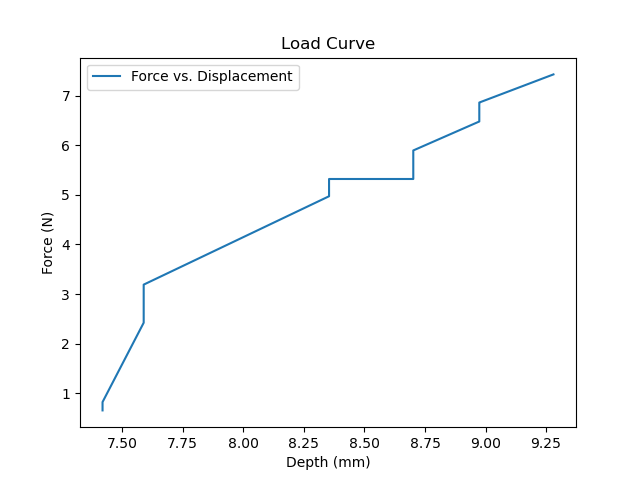

In [80]:
plt.figure()
plt.plot(h_mm, fz, label="Force vs. Displacement")
plt.xlabel("Depth (mm)")
plt.ylabel("Force (N)")
plt.title("Load Curve")
plt.legend()
